Daily Challenge

In [19]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/sample_data/global_power_plant_database.csv')
df

/tmp/ipykernel_2547/2518404118.py:4: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/sample_data/global_power_plant_database.csv')


,country,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,primary_fuel,other_fuel1,other_fuel2,...,estimated_generation_gwh_2013,estimated_generation_gwh_2014,estimated_generation_gwh_2015,estimated_generation_gwh_2016,estimated_generation_gwh_2017,estimated_generation_note_2013,estimated_generation_note_2014,estimated_generation_note_2015,estimated_generation_note_2016,estimated_generation_note_2017
0,AFG,Afghanistan,Kajaki Hydroelectric Power Plant Afghanistan,GEODB0040538,33.0,32.3220,65.1190,Hydro,NaN,NaN,...,123.77,162.90,97.39,137.76,119.50,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
1,AFG,Afghanistan,Kandahar DOG,WKS0070144,10.0,31.6700,65.7950,Solar,NaN,NaN,...,18.43,17.48,18.25,17.70,18.29,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
2,AFG,Afghanistan,Kandahar JOL,WKS0071196,10.0,31.6230,65.7920,Solar,NaN,NaN,...,18.64,17.58,19.10,17.62,18.72,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
3,AFG,Afghanistan,Mahipar Hydroelectric Power Plant Afghanistan,GEODB0040541,66.0,34.5560,69.4787,Hydro,NaN,NaN,...,225.06,203.55,146.90,230.18,174.91,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
4,AFG,Afghanistan,Naghlu Dam Hydroelectric Power Plant Afghanistan,GEODB0040534,100.0,34.6410,69.7170,Hydro,NaN,NaN,...,406.16,357.22,270.99,395.38,350.80,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34931,ZMB,Zambia,Ndola,WRI1022386,50.0,-12.9667,28.6333,Oil,NaN,NaN,...,NaN,NaN,NaN,NaN,183.79,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,CAPACITY-FACTOR-V1
34932,ZMB,Zambia,Nkana,WRI1022384,20.0,-12.8167,28.2000,Oil,NaN,NaN,...,NaN,NaN,NaN,NaN,73.51,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,CAPACITY-FACTOR-V1
34933,ZMB,Zambia,Victoria Falls,WRI1022380,108.0,-17.9167,25.8500,Hydro,NaN,NaN,...,575.78,575.78,548.94,579.90,578.32,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
34934,ZWE,Zimbabwe,Hwange Coal Power Plant Zimbabwe,GEODB0040404,920.0,-18.3835,26.4700,Coal,NaN,NaN,...,NaN,NaN,NaN,NaN,2785.10,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,CAPACITY-FACTOR-V1


In [ ]:
import numpy as np

# Liste des colonnes à convertir
numeric_cols = ['capacity_mw', 'latitude', 'longitude']

for col in numeric_cols:
    # Utilisation de NumPy pour convertir les valeurs en flottants (float64)
    # On remplace d'abord les valeurs non convertibles par NaN via Pandas pour la sécurité,
    # puis on s'assure que le stockage interne utilise les types NumPy.
    df[col] = pd.to_numeric(df[col], errors='coerce').to_numpy(dtype=np.float64)

# Vérification avec les types NumPy
print("Types de colonnes (NumPy) :")
for col in numeric_cols:
    print(f"{col}: {df[col].values.dtype}")

display(df[numeric_cols].head())

In [20]:
import numpy as np
import pandas as pd

# 1. Nettoyage des données
# Identification des colonnes numériques
numeric_cols = ['capacity_mw', 'latitude', 'longitude']

# Gestion des valeurs manquantes : Remplissage par la médiane pour les colonnes numériques
for col in numeric_cols:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

print("Nettoyage terminé. Valeurs manquantes restantes :")
print(df[numeric_cols].isnull().sum())

# 2. Analyse exploratoire
print("\n--- Statistiques Clés (Pandas) ---")
stats = df[numeric_cols].describe().loc[['mean', '50%', 'std']]
stats.index = ['Moyenne', 'Médiane', 'Écart-type']
display(stats)

print("\n--- Top 5 Types de Carburant ---")
print(df['primary_fuel'].value_counts().head(5))

print("\n--- Top 5 Pays ---")
print(df['country_long'].value_counts().head(5))

Nettoyage terminé. Valeurs manquantes restantes :
capacity_mw    0
latitude       0
longitude      0
dtype: int64

--- Statistiques Clés (Pandas) ---


,capacity_mw,latitude,longitude
Moyenne,163.355148,32.816637,-6.972803
Médiane,16.745000,39.727750,-2.127100
Écart-type,489.636072,22.638603,78.405850



--- Top 5 Types de Carburant ---
primary_fuel
Solar    10665
Hydro     7156
Wind      5344
Gas       3998
Coal      2330
Name: count, dtype: int64

--- Top 5 Pays ---
country_long
United States of America    9833
China                       4235
United Kingdom              2751
Brazil                      2360
France                      2155
Name: count, dtype: int64


In [21]:
import scipy.stats as stats

# 3. Analyse statistique de la puissance (capacity_mw) par type de carburant
fuels = df['primary_fuel'].unique()
fuel_groups = []

print("--- Puissance moyenne par type de carburant (NumPy) ---")
for fuel in fuels:
    # Extraction des données en tableau NumPy pour le calcul
    capacity_data = df[df['primary_fuel'] == fuel]['capacity_mw'].to_numpy()
    fuel_groups.append(capacity_data)

    avg = np.mean(capacity_data)
    std = np.std(capacity_data)
    print(f"{fuel}: Moyenne = {avg:.2f} MW, Écart-type = {std:.2f}")

# Test d'hypothèse (ANOVA) pour déterminer si les moyennes diffèrent significativement
# H0: Toutes les moyennes de puissance sont égales selon le carburant
f_stat, p_value = stats.f_oneway(*[group for group in fuel_groups if len(group) > 0])

print(f"\nRésultat du test ANOVA :")
print(f"Statistique F : {f_stat:.2f}")
print(f"P-value : {p_value:.4e}")

if p_value < 0.05:
    print("\nRésultat : On rejette l'hypothèse nulle. La puissance moyenne diffère significativement selon le type de carburant.")
else:
    print("\nRésultat : On ne peut pas rejeter l'hypothèse nulle.")

--- Puissance moyenne par type de carburant (NumPy) ---
Hydro: Moyenne = 147.17 MW, Écart-type = 549.77
Solar: Moyenne = 17.66 MW, Écart-type = 41.94
Gas: Moyenne = 373.45 MW, Écart-type = 560.86
Other: Moyenne = 84.02 MW, Écart-type = 144.19
Oil: Moyenne = 112.88 MW, Écart-type = 391.92
Wind: Moyenne = 49.22 MW, Écart-type = 106.13
Nuclear: Moyenne = 2091.86 MW, Écart-type = 1300.16
Coal: Moyenne = 843.58 MW, Écart-type = 888.00
Waste: Moyenne = 13.81 MW, Écart-type = 20.57
Biomass: Moyenne = 23.97 MW, Écart-type = 39.45
Wave and Tidal: Moyenne = 55.22 MW, Écart-type = 96.24
Petcoke: Moyenne = 202.05 MW, Écart-type = 456.68
Geothermal: Moyenne = 67.13 MW, Écart-type = 114.34
Storage: Moyenne = 12.68 MW, Écart-type = 35.44
Cogeneration: Moyenne = 98.73 MW, Écart-type = 279.95

Résultat du test ANOVA :
Statistique F : 967.46
P-value : 0.0000e+00

Résultat : On rejette l'hypothèse nulle. La puissance moyenne diffère significativement selon le type de carburant.


In [22]:
# 4. Analyse des séries chronologiques
# On commence par nettoyer la colonne 'commissioning_year'
df['commissioning_year'] = pd.to_numeric(df['commissioning_year'], errors='coerce')
df_time = df.dropna(subset=['commissioning_year'])

# Utilisation de NumPy pour extraire les années uniques et les carburants
years = np.sort(df_time['commissioning_year'].unique().astype(int))

print(f"Analyse de {years.min()} à {years.max()}")

# Évolution de la capacité totale par année (Top 5 carburants)
top_fuels = df['primary_fuel'].value_counts().head(5).index

print("\n--- Évolution de la capacité (MW) par décennie (NumPy) ---")
# Création de groupes par décennie
df_time['decade'] = (df_time['commissioning_year'] // 10) * 10
decades = np.sort(df_time['decade'].unique().astype(int))

for decade in decades[-6:]: # Focus sur les 6 dernières décennies
    decade_data = df_time[df_time['decade'] == decade]
    total_cap = np.sum(decade_data['capacity_mw'].to_numpy())
    print(f"Années {decade}s : {total_cap:,.0f} MW installés")

Analyse de 1896 à 2020

--- Évolution de la capacité (MW) par décennie (NumPy) ---
Années 1970s : 423,165 MW installés
Années 1980s : 428,326 MW installés
Années 1990s : 396,792 MW installés
Années 2000s : 1,163,572 MW installés
Années 2010s : 1,057,647 MW installés
Années 2020s : 5,696 MW installés


/tmp/ipykernel_2547/1385207113.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_time['decade'] = (df_time['commissioning_year'] // 10) * 10


/tmp/ipykernel_2547/2236456037.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='primary_fuel', y='capacity_mw', data=df, estimator=np.mean, palette='viridis')


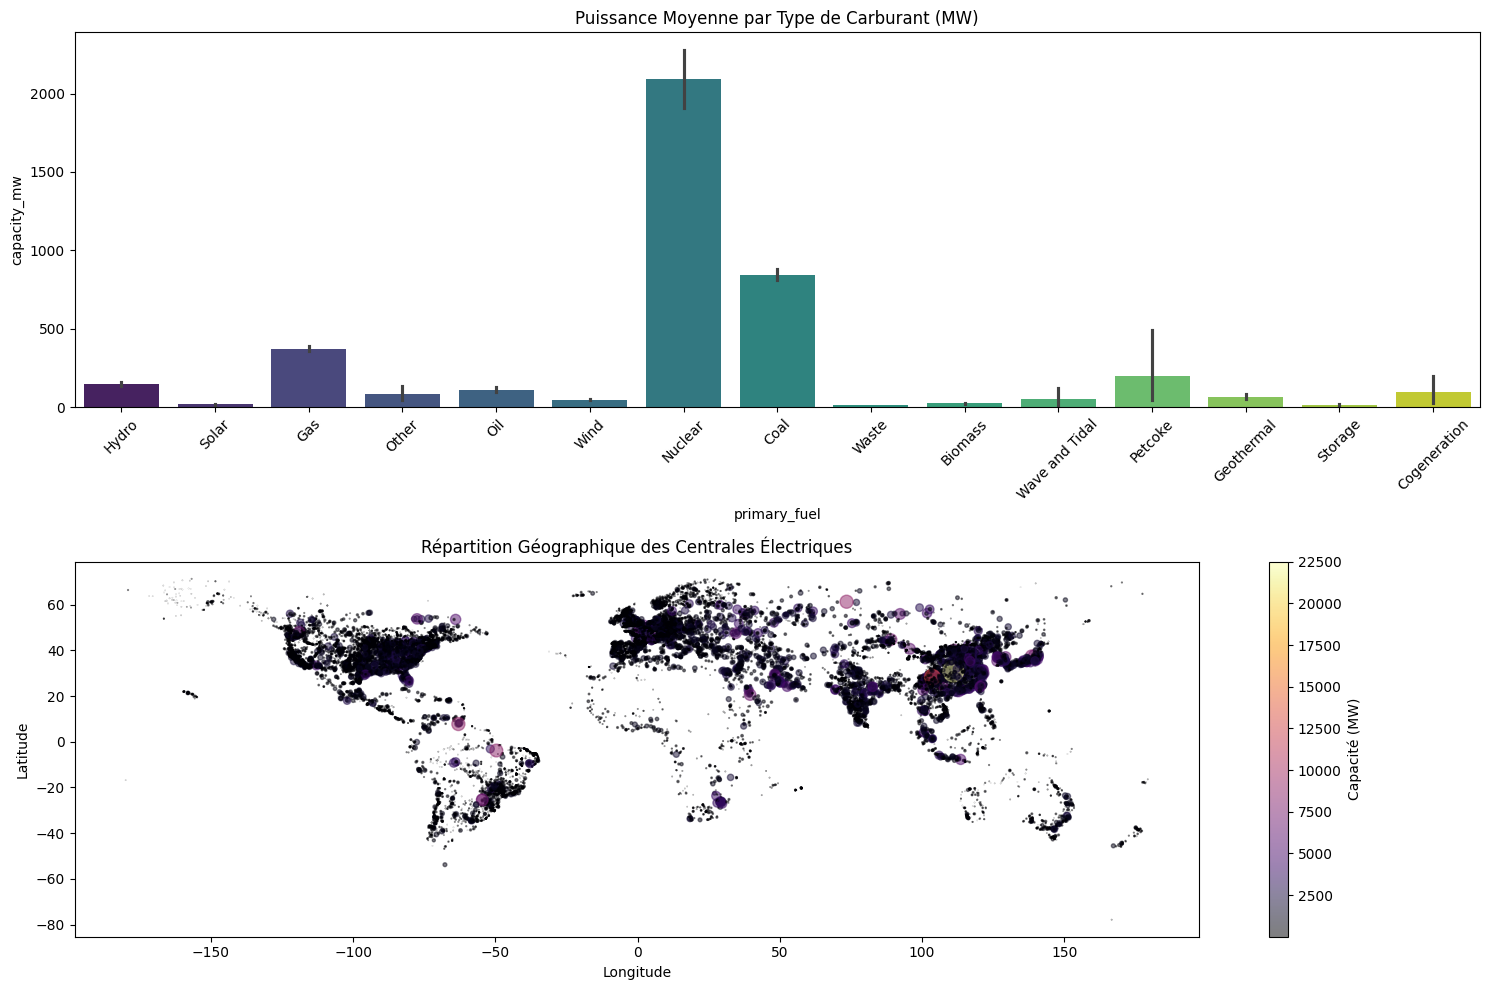


--- Opérations Matricielles --- 
Matrice de Corrélation (NumPy) :
[[ 1.         -0.01321759  0.15152454]
 [-0.01321759  1.         -0.06835441]
 [ 0.15152454 -0.06835441  1.        ]]

Valeurs propres : [1.17147434 0.83840686 0.9901188 ]

Les vecteurs propres indiquent les directions de variance maximale (pertinent pour une ACP).


In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# 5. Visualisation avancée
plt.figure(figsize=(15, 10))

# Graphique 1: Capacité par type de carburant
plt.subplot(2, 1, 1)
sns.barplot(x='primary_fuel', y='capacity_mw', data=df, estimator=np.mean, palette='viridis')
plt.title('Puissance Moyenne par Type de Carburant (MW)')
plt.xticks(rotation=45)

# Graphique 2: Répartition géographique
plt.subplot(2, 1, 2)
plt.scatter(df['longitude'], df['latitude'], c=df['capacity_mw'], cmap='inferno', alpha=0.5, s=df['capacity_mw']/100)
plt.colorbar(label='Capacité (MW)')
plt.title('Répartition Géographique des Centrales Électriques')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.tight_layout()
plt.show()

# 6. Opérations matricielles
print("\n--- Opérations Matricielles --- ")
# Création d'une matrice de corrélation pour les variables numériques
features = df[['capacity_mw', 'latitude', 'longitude']].to_numpy()
correlation_matrix = np.corrcoef(features, rowvar=False)

print("Matrice de Corrélation (NumPy) :")
print(correlation_matrix)

# Calcul des valeurs propres et vecteurs propres de la matrice de corrélation
valeurs_propres, vecteurs_propres = np.linalg.eig(correlation_matrix)
print("\nValeurs propres :", valeurs_propres)
print("\nLes vecteurs propres indiquent les directions de variance maximale (pertinent pour une ACP).")

Nombre de centrales 'géantes' détectées : 35


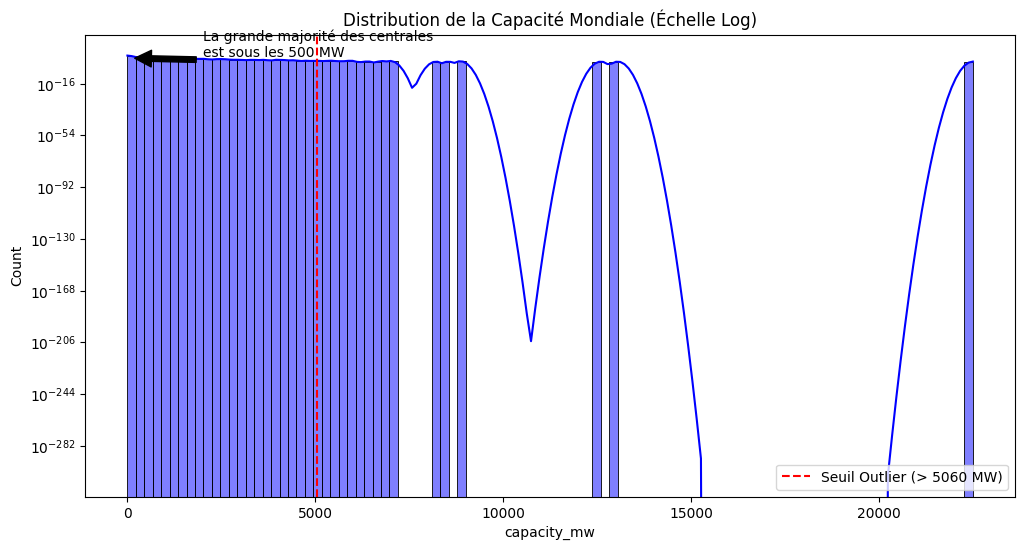

Défi terminé ! Vous pouvez maintenant exporter ce notebook et le partager sur GitHub.


In [24]:
# 7. Intégration avancée NumPy + Pandas + Matplotlib

# Calcul de la moyenne et de l'écart-type avec NumPy
mean_cap = np.mean(df['capacity_mw'])
std_cap = np.std(df['capacity_mw'])

# Filtrage complexe : Centrales ayant une capacité > 10 fois l'écart-type (les 'géants')
seuil = mean_cap + (10 * std_cap)
centrales_geantes = df[np.greater(df['capacity_mw'].to_numpy(), seuil)]

print(f"Nombre de centrales 'géantes' détectées : {len(centrales_geantes)}")

# Visualisation de l'intégration
plt.figure(figsize=(12, 6))
sns.histplot(df['capacity_mw'], bins=100, kde=True, color='blue')
plt.axvline(seuil, color='red', linestyle='--', label=f'Seuil Outlier (> {seuil:.0f} MW)')

# Utilisation de NumPy pour positionner des annotations
plt.annotate('La grande majorité des centrales\nest sous les 500 MW',
             xy=(100, 500), xytext=(2000, 5000),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.yscale('log') # Échelle logarithmique pour mieux voir la distribution
plt.title('Distribution de la Capacité Mondiale (Échelle Log)')
plt.legend()
plt.show()

print("Défi terminé ! Vous pouvez maintenant exporter ce notebook et le partager sur GitHub.")